In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ankushpanjiyar/quark-gluon/quark-gluon_data-set_n139306.hdf5


In [2]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

In [4]:
base = "/kaggle/input/datasets/ankushpanjiyar/quark-gluon"
print(os.listdir(base))

['quark-gluon_data-set_n139306.hdf5']


In [5]:
file_path = "/kaggle/input/datasets/ankushpanjiyar/quark-gluon/quark-gluon_data-set_n139306.hdf5"

with h5py.File(file_path, "r") as f:
    print(list(f.keys()))
    # Inspect shapes
    for key in f.keys():
        print(key, f[key].shape)

['X_jets', 'm0', 'pt', 'y']
X_jets (139306, 125, 125, 3)
m0 (139306,)
pt (139306,)
y (139306,)


In [7]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [6]:
class JetDataset(Dataset):
    def __init__(self, h5_path):
        self.file = h5py.File(h5_path, "r")
        self.x = self.file["X_jets"][:]       # shape: (N, 125, 125, 3)

        # OPTIONAL (labels for other tasks)
        self.y = self.file["y"][:]            # 0 = quark, 1 = gluon

        self.n = self.x.shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        img = self.x[idx]                     # (125, 125, 3)

        # Convert from (H, W, C) → (C, H, W)
        img = np.transpose(img, (2, 0, 1))

        # Normalize to [0,1]
        img = img.astype(np.float32)
        img /= img.max() + 1e-8

        return torch.tensor(img)

dataset = JetDataset(file_path)

sample = dataset[0]
print("Sample shape:", sample.shape)  # Expect (3, 125, 125)
print("Min/Max:", sample.min().item(), sample.max().item())

Sample shape: torch.Size([3, 125, 125])
Min/Max: 0.0 0.9999999403953552


In [10]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256)
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(256, 128 * 16 * 16)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.linear(x)
        x = x.view(-1, 128, 16, 16)
        return self.net(x)


class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        # Crop center 125x125
        out = out[:, :, 1:126, 1:126]

        return out

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for imgs in tqdm(train_loader):
        imgs = imgs.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss = {train_loss/len(train_loader):.6f}")

100%|██████████| 3483/3483 [01:14<00:00, 46.93it/s]


Epoch 1/20, Loss = 0.000546


100%|██████████| 3483/3483 [01:14<00:00, 46.67it/s]


Epoch 2/20, Loss = 0.000055


100%|██████████| 3483/3483 [01:14<00:00, 46.88it/s]


...

Epoch 18/20, Loss = 0.000055


100%|██████████| 3483/3483 [01:16<00:00, 45.35it/s]


Epoch 19/20, Loss = 0.000055


100%|██████████| 3483/3483 [01:16<00:00, 45.52it/s]

Epoch 20/20, Loss = 0.000055


In [15]:
model.eval()

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
      (7): Linear(in_features=32768, out_features=256, bias=True)
    )
  )
  (decoder): Decoder(
    (linear): Linear(in_features=256, out_features=32768, bias=True)
    (net): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (5): Sigmoid()
    )
  )
)

In [12]:
imgs = next(iter(val_loader))
imgs = imgs.to(device)

with torch.no_grad():
    recon = model(imgs)

imgs = imgs.cpu().numpy()
recon = recon.cpu().numpy()

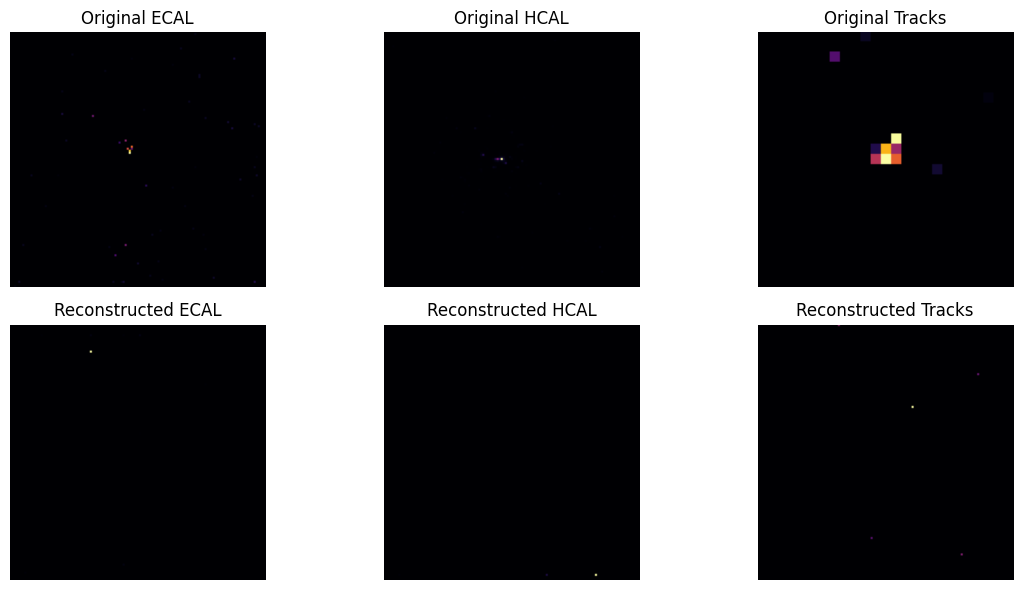

In [13]:
def plot_event(original, reconstructed, idx=0):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    channels = ["ECAL", "HCAL", "Tracks"]

    for i in range(3):
        axes[0, i].imshow(original[idx, i], cmap="inferno")
        axes[0, i].set_title(f"Original {channels[i]}")
        axes[0, i].axis("off")

        axes[1, i].imshow(reconstructed[idx, i], cmap="inferno")
        axes[1, i].set_title(f"Reconstructed {channels[i]}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

plot_event(imgs, recon, idx=0)

In [14]:
def compute_metrics(orig, rec):
    mse = np.mean((orig - rec) ** 2)
    p = psnr(orig, rec, data_range=1)
    s = ssim(orig, rec, data_range=1)
    return mse, p, s

for i, name in enumerate(["ECAL", "HCAL", "Tracks"]):
    m, p, s = compute_metrics(imgs[0, i], recon[0, i])
    print(f"{name}: MSE={m:.6f} | PSNR={p:.3f} | SSIM={s:.3f}")

ECAL: MSE=0.000138 | PSNR=38.608 | SSIM=0.977
HCAL: MSE=0.000079 | PSNR=41.021 | SSIM=0.990
Tracks: MSE=0.000001 | PSNR=60.150 | SSIM=0.995
